# Лабораторная работа 3: Нейронные сети, регуляризация и CNN

**Датасет:** MNIST (рукописные цифры)

## Содержание
1. Загрузка данных
2. Модель с регуляризацией и ReLU (базовая)
3. Модель без регуляризации
4. Модель с сигмоидой вместо ReLU
5. CNN с визуализацией активаций
6. Теоретический минимум

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Воспроизводимость
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cpu


## 1. Загрузка и подготовка данных MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


Обучающих примеров: 60000
Тестовых примеров:  10000


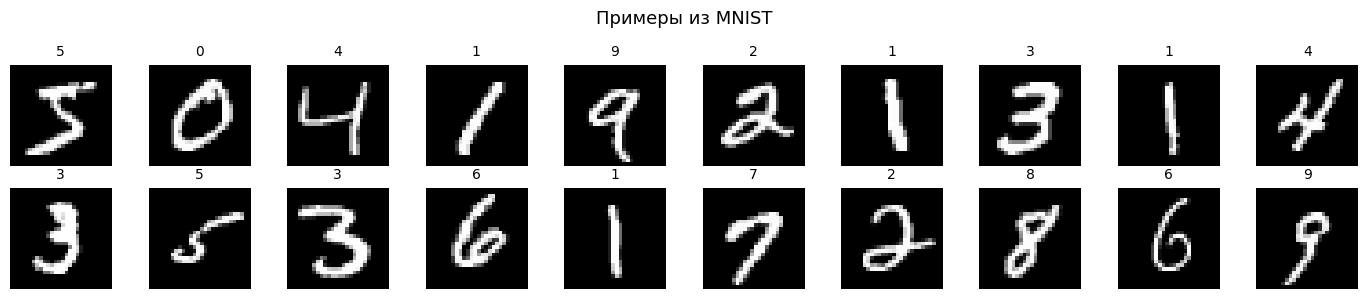

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # среднее и std MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f'Обучающих примеров: {len(train_dataset)}')
print(f'Тестовых примеров:  {len(test_dataset)}')

# Визуализация нескольких примеров
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    img, label = train_dataset[i]
    axes[i // 10, i % 10].imshow(img.squeeze(), cmap='gray')
    axes[i // 10, i % 10].set_title(str(label), fontsize=10)
    axes[i // 10, i % 10].axis('off')
plt.suptitle('Примеры из MNIST', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Утилиты: обучение и оценка

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total


def run_training(model, epochs=20, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, test_loader,  criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:>2}/{epochs}  '
                  f'Train Loss: {tr_loss:.4f}  Val Loss: {vl_loss:.4f}  '
                  f'Train Acc: {tr_acc:.4f}  Val Acc: {vl_acc:.4f}')
    return history


def plot_history(histories, labels, title='Сравнение моделей'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['royalblue', 'tomato', 'seagreen', 'orange']

    for i, (hist, label) in enumerate(zip(histories, labels)):
        epochs = range(1, len(hist['train_loss']) + 1)
        c = colors[i % len(colors)]
        axes[0].plot(epochs, hist['train_loss'], linestyle='--', color=c, alpha=0.6, label=f'{label} (train)')
        axes[0].plot(epochs, hist['val_loss'],   linestyle='-',  color=c,            label=f'{label} (val)')
        axes[1].plot(epochs, hist['train_acc'],  linestyle='--', color=c, alpha=0.6, label=f'{label} (train)')
        axes[1].plot(epochs, hist['val_acc'],    linestyle='-',  color=c,            label=f'{label} (val)')

    axes[0].set_title('Функция потерь (Loss)')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Точность (Accuracy)')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. Базовая модель: MLP с регуляризацией (Dropout + L2) и ReLU

In [ ]:
class MLPWithRegularization(nn.Module):
    """
    Полносвязная сеть (MLP) с:
      - функцией активации ReLU
      - Dropout (p=0.3) как регуляризация
      - BatchNorm для стабилизации обучения
    Архитектура: 784 -> 512 -> 256 -> 128 -> 10
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


print('=== Модель с регуляризацией (ReLU + Dropout + BatchNorm) ===')
model_reg = MLPWithRegularization()
print(model_reg)
total_params = sum(p.numel() for p in model_reg.parameters())
print(f'\nВсего параметров: {total_params:,}')

=== Модель с регуляризацией (ReLU + Dropout + BatchNorm) ===
MLPWithRegularization(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)

Всего параметров: 569,226


In [ ]:
EPOCHS = 25
print('Обучение базовой модели (с регуляризацией)...')
history_reg = run_training(model_reg, epochs=EPOCHS)

Обучение базовой модели (с регуляризацией)...
Epoch  1/25  Train Loss: 0.3378  Val Loss: 0.1126  Train Acc: 0.9114  Val Acc: 0.9667
Epoch  5/25  Train Loss: 0.0671  Val Loss: 0.0619  Train Acc: 0.9788  Val Acc: 0.9810
Epoch 10/25  Train Loss: 0.0416  Val Loss: 0.0564  Train Acc: 0.9863  Val Acc: 0.9825
Epoch 15/25  Train Loss: 0.0294  Val Loss: 0.0564  Train Acc: 0.9901  Val Acc: 0.9831
Epoch 20/25  Train Loss: 0.0226  Val Loss: 0.0552  Train Acc: 0.9928  Val Acc: 0.9852
Epoch 25/25  Train Loss: 0.0183  Val Loss: 0.0547  Train Acc: 0.9937  Val Acc: 0.9844


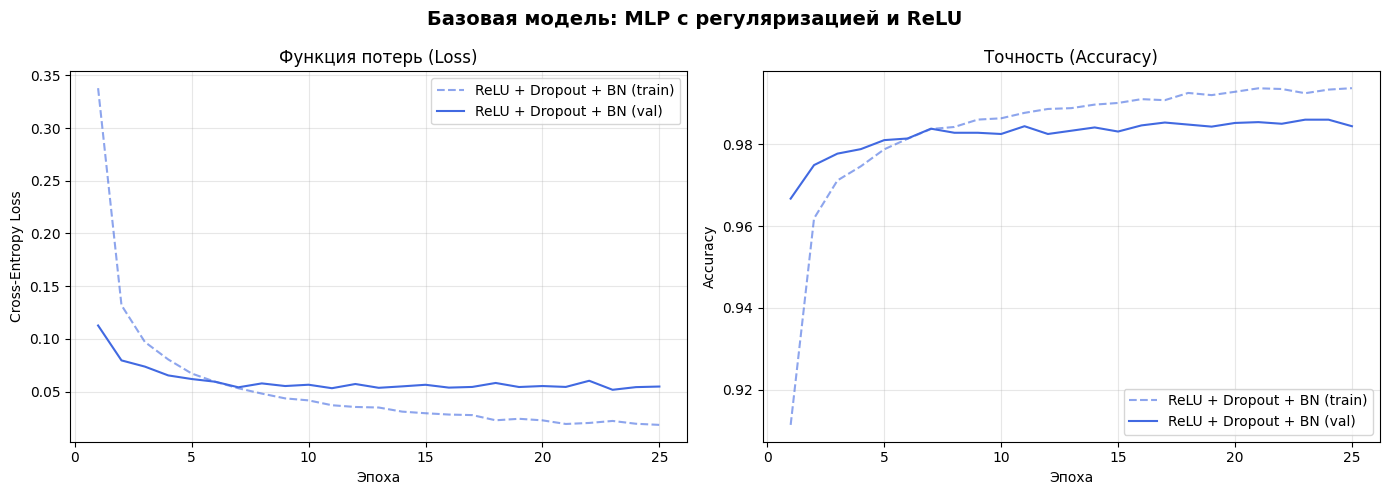

Итоговая точность на тесте: 0.9844 (98.44%)


In [ ]:
plot_history([history_reg], ['ReLU + Dropout + BN'],
             title='Базовая модель: MLP с регуляризацией и ReLU')

final_val_acc = history_reg['val_acc'][-1]
print(f'Итоговая точность на тесте: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)')

## 4. Модель БЕЗ регуляризации — сравнение

In [ ]:
class MLPNoRegularization(nn.Module):
    """
    Та же архитектура, но БЕЗ Dropout и BatchNorm.
    Ожидаемый эффект: переобучение — train loss падает,
    но val loss растёт после нескольких эпох.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


print('=== Модель БЕЗ регуляризации ===')
model_noreg = MLPNoRegularization()
history_noreg = run_training(model_noreg, epochs=EPOCHS)

=== Модель БЕЗ регуляризации ===
Epoch  1/25  Train Loss: 0.3175  Val Loss: 0.1430  Train Acc: 0.9067  Val Acc: 0.9565
Epoch  5/25  Train Loss: 0.0406  Val Loss: 0.0744  Train Acc: 0.9865  Val Acc: 0.9767
Epoch 10/25  Train Loss: 0.0186  Val Loss: 0.0755  Train Acc: 0.9938  Val Acc: 0.9803
Epoch 15/25  Train Loss: 0.0131  Val Loss: 0.0967  Train Acc: 0.9957  Val Acc: 0.9803
Epoch 20/25  Train Loss: 0.0062  Val Loss: 0.1058  Train Acc: 0.9981  Val Acc: 0.9795
Epoch 25/25  Train Loss: 0.0077  Val Loss: 0.0946  Train Acc: 0.9976  Val Acc: 0.9800


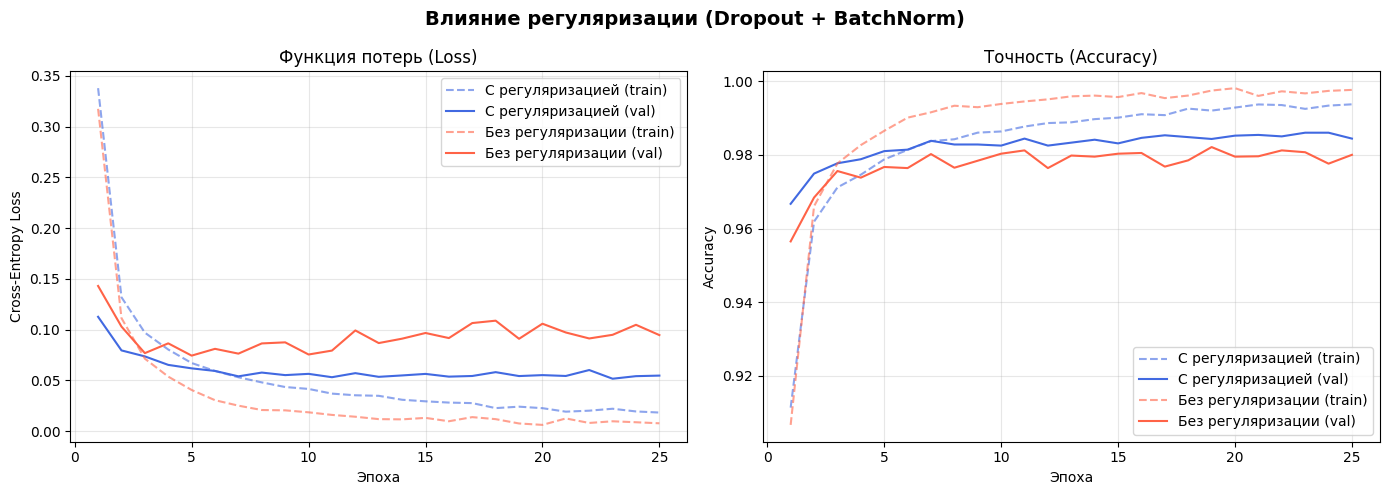

Итоговые метрики:
  С регуляризацией   — Train: 0.9937, Val: 0.9844
  Без регуляризации  — Train: 0.9976, Val: 0.9800

Разрыв train/val без регуляризации: 0.0176 (переобучение)


In [ ]:
# Сравнение базовой модели и модели без регуляризации
plot_history(
    [history_reg, history_noreg],
    ['С регуляризацией', 'Без регуляризации'],
    title='Влияние регуляризации (Dropout + BatchNorm)'
)

print('Итоговые метрики:')
print(f'  С регуляризацией   — Train: {history_reg["train_acc"][-1]:.4f}, Val: {history_reg["val_acc"][-1]:.4f}')
print(f'  Без регуляризации  — Train: {history_noreg["train_acc"][-1]:.4f}, Val: {history_noreg["val_acc"][-1]:.4f}')

overfitting_gap = history_noreg['train_acc'][-1] - history_noreg['val_acc'][-1]
print(f'\nРазрыв train/val без регуляризации: {overfitting_gap:.4f} (переобучение)')

### Вывод по регуляризации

Без Dropout и BatchNorm модель **переобучается**: train accuracy выше val accuracy. Dropout случайно "отключает" нейроны во время обучения, вынуждая сеть учить более устойчивые признаки. BatchNorm нормализует активации, снижая internal covariate shift и оказывая дополнительный регуляризующий эффект.

## 5. Замена ReLU на Sigmoid — сравнение

In [ ]:
class MLPSigmoid(nn.Module):
    """
    Та же архитектура с регуляризацией, но вместо ReLU — Sigmoid.
    Проблема: затухающий градиент (vanishing gradient).
    sigmoid'(x) = sigmoid(x)(1-sigmoid(x)) ∈ (0, 0.25]
    При глубоких сетях градиент перемножается и стремится к 0.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.Sigmoid(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


print('=== Модель с Sigmoid ===')
model_sigmoid = MLPSigmoid()
history_sigmoid = run_training(model_sigmoid, epochs=EPOCHS)

=== Модель с Sigmoid ===
Epoch  1/25  Train Loss: 0.9714  Val Loss: 0.4218  Train Acc: 0.8044  Val Acc: 0.9040
Epoch  5/25  Train Loss: 0.2585  Val Loss: 0.1710  Train Acc: 0.9245  Val Acc: 0.9500
Epoch 10/25  Train Loss: 0.1431  Val Loss: 0.0938  Train Acc: 0.9573  Val Acc: 0.9712
Epoch 15/25  Train Loss: 0.0953  Val Loss: 0.0751  Train Acc: 0.9702  Val Acc: 0.9761
Epoch 20/25  Train Loss: 0.0701  Val Loss: 0.0654  Train Acc: 0.9776  Val Acc: 0.9803
Epoch 25/25  Train Loss: 0.0547  Val Loss: 0.0648  Train Acc: 0.9825  Val Acc: 0.9806


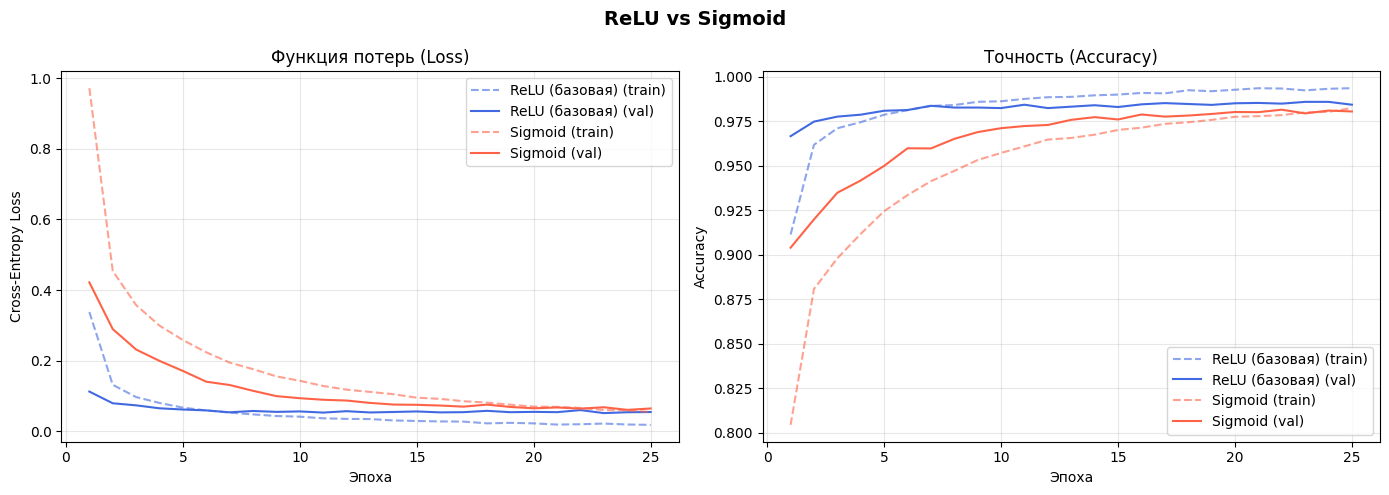

Итоговые метрики:
  ReLU     — Train: 0.9937, Val: 0.9844
  Sigmoid  — Train: 0.9825, Val: 0.9806


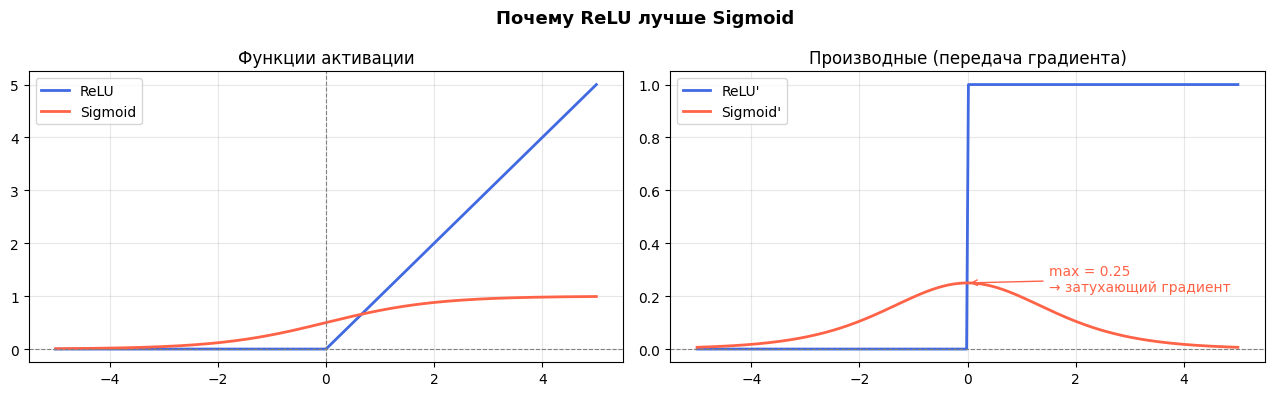

In [ ]:
plot_history(
    [history_reg, history_sigmoid],
    ['ReLU (базовая)', 'Sigmoid'],
    title='ReLU vs Sigmoid'
)

print('Итоговые метрики:')
print(f'  ReLU     — Train: {history_reg["train_acc"][-1]:.4f}, Val: {history_reg["val_acc"][-1]:.4f}')
print(f'  Sigmoid  — Train: {history_sigmoid["train_acc"][-1]:.4f}, Val: {history_sigmoid["val_acc"][-1]:.4f}')

# Визуализация функций активации
x = np.linspace(-5, 5, 300)
relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
relu_d  = (x > 0).astype(float)
sigmoid_d = sigmoid * (1 - sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x, relu,    color='royalblue', lw=2, label='ReLU')
axes[0].plot(x, sigmoid, color='tomato',    lw=2, label='Sigmoid')
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[0].axvline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_title('Функции активации')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x, relu_d,    color='royalblue', lw=2, label="ReLU'")
axes[1].plot(x, sigmoid_d, color='tomato',    lw=2, label="Sigmoid'")
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_title('Производные (передача градиента)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].annotate('max = 0.25\n→ затухающий градиент', xy=(0, 0.25),
                  xytext=(1.5, 0.22), color='tomato',
                  arrowprops=dict(arrowstyle='->', color='tomato'))

plt.suptitle('Почему ReLU лучше Sigmoid', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Вывод: почему Sigmoid хуже ReLU

**Проблема затухающего градиента (Vanishing Gradient):**
- Производная sigmoid: $\sigma'(x) = \sigma(x)(1-\sigma(x)) \leq 0.25$
- При backprop через 3 слоя максимальный вклад: $0.25^3 = 0.016$
- Градиенты первых слоёв стремятся к нулю → они почти не обновляются

**ReLU:** производная равна 1 для $x > 0$ → градиент не затухает (но возможна проблема «мёртвых нейронов» при $x < 0$)

## 6. CNN и визуализация активаций

In [ ]:
class SimpleCNN(nn.Module):
    """
    CNN для MNIST.
    Архитектура:
      Conv1: 1->16 каналов, ядро 3x3  -> 28x28x16
      Pool:  MaxPool 2x2               -> 14x14x16
      Conv2: 16->32 каналов, ядро 3x3 -> 14x14x32
      Pool:  MaxPool 2x2               ->  7x7x32
      FC: 7*7*32 -> 128 -> 10
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.25)
        self.fc1   = nn.Linear(32 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # -> 14x14x16
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # ->  7x7x32
        x = x.view(x.size(0), -1)                         # flatten
        x = self.drop(self.relu(self.fc1(x)))
        return self.fc2(x)

    def get_activations(self, x):
        """Возвращает активации после каждого сверточного слоя."""
        act1 = self.relu(self.bn1(self.conv1(x)))
        act1_pooled = self.pool(act1)
        act2 = self.relu(self.bn2(self.conv2(act1_pooled)))
        return act1, act2


print('=== CNN ===')
model_cnn = SimpleCNN().to(device)
print(model_cnn)
print(f'Параметров: {sum(p.numel() for p in model_cnn.parameters()):,}')

=== CNN ===
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (drop): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Параметров: 207,018


In [ ]:
print('Обучение CNN...')
history_cnn = run_training(model_cnn, epochs=EPOCHS)

plot_history([history_cnn], ['CNN'],
             title='CNN на MNIST')
print(f'Итоговая точность CNN на тесте: {history_cnn["val_acc"][-1]:.4f}')

In [ ]:
# ---- Визуализация активаций первых слоёв CNN ----
model_cnn.eval()

# Берём один пример каждого класса
sample_images, sample_labels = [], []
seen = set()
for img, lbl in test_dataset:
    if lbl not in seen:
        sample_images.append(img)
        sample_labels.append(lbl)
        seen.add(lbl)
    if len(seen) == 10:
        break

# Берём цифру '7' для наглядной визуализации
idx = sample_labels.index(7)
sample = sample_images[idx].unsqueeze(0).to(device)

with torch.no_grad():
    act1, act2 = model_cnn.get_activations(sample)

act1_np = act1.squeeze().cpu().numpy()  # (16, 28, 28)
act2_np = act2.squeeze().cpu().numpy()  # (32, 14, 14)

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(3, 17, figure=fig, hspace=0.4, wspace=0.2)

# Исходное изображение
ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(sample_images[idx].squeeze(), cmap='gray')
ax_orig.set_title('Input\n(digit 7)', fontsize=9)
ax_orig.axis('off')

# Активации Conv1 (16 карт)
for i in range(16):
    row = i // 8
    col = (i % 8) + 1
    ax = fig.add_subplot(gs[row, col + 1])
    ax.imshow(act1_np[i], cmap='viridis')
    ax.set_title(f'C1-{i}', fontsize=6)
    ax.axis('off')

# Активации Conv2 (первые 16 из 32)
for i in range(16):
    row = i // 8
    col = (i % 8) + 1
    ax = fig.add_subplot(gs[row + 1, col + 1])
    if i < len(act2_np):
        ax.imshow(act2_np[i], cmap='plasma')
        ax.set_title(f'C2-{i}', fontsize=6)
    ax.axis('off')

fig.suptitle('Активации первых двух сверточных слоёв CNN (цифра "7")',
             fontsize=13, fontweight='bold')
plt.show()

print('Визуализация фильтров (ядер свёртки) первого слоя:')
conv1_weights = model_cnn.conv1.weight.data.cpu().numpy()  # (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    w = conv1_weights[i, 0]
    im = ax.imshow(w, cmap='RdBu_r', vmin=-w.abs().max(), vmax=w.abs().max())
    ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Фильтры (ядра свёртки) первого слоя CNN', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Итоговое сравнение всех 4 моделей
plot_history(
    [history_reg, history_noreg, history_sigmoid, history_cnn],
    ['MLP + Reg + ReLU', 'MLP без Reg', 'MLP + Sigmoid', 'CNN'],
    title='Сводное сравнение всех моделей'
)

print('\n=== ИТОГОВАЯ ТАБЛИЦА ===')
print(f'{"Модель":<25} {"Train Acc":>10} {"Val Acc":>10} {"Val Loss":>10}')
print('-' * 58)
for name, hist in [
    ('MLP + Reg + ReLU',   history_reg),
    ('MLP без Reg',        history_noreg),
    ('MLP + Sigmoid',      history_sigmoid),
    ('CNN',                history_cnn),
]:
    print(f'{name:<25} {hist["train_acc"][-1]:>10.4f} {hist["val_acc"][-1]:>10.4f} {hist["val_loss"][-1]:>10.4f}')

---
# Теоретический минимум

## 1. Математическая модель нейрона

Нейрон вычисляет **линейную комбинацию** входных сигналов, затем пропускает результат через функцию активации:

$$y = f\!\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(\mathbf{w}^\top \mathbf{x} + b)$$

где $\mathbf{x} \in \mathbb{R}^n$ — вход, $\mathbf{w} \in \mathbb{R}^n$ — веса (обучаемые), $b \in \mathbb{R}$ — смещение (bias), $f$ — функция активации (нелинейность).

---

## 2. Функции активации

Функции активации вносят **нелинейность**, без которой сеть любой глубины была бы эквивалентна одному линейному слою.

| Название | Формула | Область значений | Плюсы | Минусы |
|----------|---------|-----------------|-------|--------|
| **Sigmoid** | $\sigma(x)=\frac{1}{1+e^{-x}}$ | $(0, 1)$ | Вероятностная интерпретация | Затухающий градиент, смещение от нуля |
| **Tanh** | $\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$ | $(-1, 1)$ | Центрирован вокруг 0 | Затухающий градиент |
| **ReLU** | $\max(0, x)$ | $[0, +\infty)$ | Нет затухания (x>0), быстрый | «Мёртвые нейроны» при x<0 |
| **Leaky ReLU** | $\max(\alpha x, x),\ \alpha\!\approx\!0.01$ | $(-\infty, +\infty)$ | Нет мёртвых нейронов | Гиперпараметр $\alpha$ |
| **Softmax** | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | $(0,1)$, сумма=1 | Распределение вероятностей | Только для выходного слоя |

---

## 3. Forward Pass

Прямой проход — последовательное применение операций от входа к выходу:

1. **Вход** $\mathbf{x}^{(0)} = \mathbf{x}$ (например, пиксели изображения)
2. Для каждого слоя $l = 1, \ldots, L$:
   - **Линейная комбинация:** $\mathbf{z}^{(l)} = W^{(l)} \mathbf{x}^{(l-1)} + \mathbf{b}^{(l)}$
   - **Активация:** $\mathbf{x}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$
3. **Выход** $\hat{\mathbf{y}} = \mathbf{x}^{(L)}$ (логиты → softmax → вероятности)
4. **Функция потерь** $\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})$, например Cross-Entropy:
$$\mathcal{L} = -\sum_k y_k \log \hat{y}_k$$

---

## 4. Backward Pass (Backpropagation)

Цель — вычислить $\frac{\partial \mathcal{L}}{\partial W^{(l)}}$ для каждого слоя через **цепное правило**.

**Алгоритм:**

1. Вычислить ошибку выходного слоя: $\boldsymbol{\delta}^{(L)} = \nabla_{\mathbf{x}^{(L)}} \mathcal{L} \odot f'^{(L)}(\mathbf{z}^{(L)})$

2. Для каждого слоя $l = L-1, \ldots, 1$ — распространить ошибку назад:
$$\boldsymbol{\delta}^{(l)} = \left(W^{(l+1)\top} \boldsymbol{\delta}^{(l+1)}\right) \odot f'^{(l)}(\mathbf{z}^{(l)})$$

3. Вычислить градиенты весов:
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \boldsymbol{\delta}^{(l)} \mathbf{x}^{(l-1)\top}, \qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$$

---

## 5. Градиентный спуск

**Определение:** итеративная оптимизация параметров в направлении антиградиента:
$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)$$
где $\eta$ — learning rate.

**Минусы классического (batch) GD:**
- Нужно считать градиент по **всему** датасету → медленно
- Застревает в локальных минимумах и сёдловых точках
- Нет возможности онлайн-обучения

---

## 6. Стохастический градиентный спуск (SGD)

$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta; \mathbf{x}^{(i)}, y^{(i)})$$

Обновление происходит по **одному** примеру (или мини-батчу). Отличия от batch GD:

| | Batch GD | SGD / Mini-batch SGD |
|--|----------|----------------------|
| Градиент | Точный | Зашумлённая оценка |
| Скорость итерации | Медленная | Быстрая |
| Сходимость | Стабильная | Осциллирует, но обобщает лучше |
| Память | Весь датасет | Один батч |

**Шум SGD** помогает вырваться из локальных минимумов → лучшая обобщающая способность.

---

## 7. Оптимизаторы

### Momentum
Добавляет «инерцию» — накапливает экспоненциально взвешенное среднее градиентов:
$$v_t = \beta v_{t-1} + (1-\beta) g_t, \qquad \theta \leftarrow \theta - \eta v_t$$
Ускоряет обучение в направлениях с постоянным градиентом и гасит осцилляции.

### Nesterov Accelerated Gradient (NAG)
Смотрит «вперёд» — считает градиент в предполагаемой следующей точке:
$$v_t = \beta v_{t-1} + \eta \nabla_\theta \mathcal{L}(\theta - \beta v_{t-1})$$
$$\theta \leftarrow \theta - v_t$$
Более точная коррекция, чем Momentum.

### RMSProp
Адаптирует learning rate для каждого параметра, деля на корень среднеквадратичного градиента:
$$s_t = \rho s_{t-1} + (1-\rho) g_t^2$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$
Полезен для несбалансированных градиентов (RNN).

### Adam (Adaptive Moment Estimation)
Комбинирует Momentum (1-й момент) и RMSProp (2-й момент) + bias correction:
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{(1-й момент)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{(2-й момент)}$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{(bias correction)}$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$
Типичные значения: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$. Де-факто стандарт для глубокого обучения.

---

## 8. Регуляризация и BatchNorm

### L2-регуляризация (Weight Decay)
Добавляет штраф к функции потерь:
$$\mathcal{L}_{reg} = \mathcal{L} + \lambda \|\mathbf{w}\|_2^2$$
Стягивает веса к нулю, препятствуя слишком большим весам.

### Dropout
Во время обучения каждый нейрон с вероятностью $p$ обнуляется ("выключается"), оставшиеся масштабируются на $\frac{1}{1-p}$:
$$\tilde{h}_i = \frac{r_i}{1-p} h_i, \quad r_i \sim \text{Bernoulli}(1-p)$$
**При инференсе** Dropout отключается — используются все нейроны.

**Эффект:** сеть не может полагаться на конкретные нейроны → учит более устойчивые и распределённые признаки. Эквивалентно ансамблированию $2^n$ подсетей.

### Batch Normalization
Нормализует активации внутри мини-батча:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$
где $\mu_B, \sigma_B^2$ — среднее и дисперсия по батчу; $\gamma, \beta$ — обучаемые параметры (scale & shift).

**Зачем нужно:**
- Устраняет *internal covariate shift* — нестабильное распределение активаций между слоями
- Позволяет использовать большой learning rate
- Оказывает регуляризующий эффект (шум от батча)
- Ускоряет сходимость